# Plotting the Density of States files

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

In [10]:
# Data files

filenames = ["dos_1.dat", "dos_2.dat", "dos_3.dat", "dos_4.dat", "dos_5.dat", "dos_6.dat", "dos_7.dat", "dos_8.dat", "dos_9.dat", "dos_10.dat"]
paths_to_compare = ["4-3neb-H2/neb_sccs", "4-10neb-H2-loose/neb"]

# Extract the Fermi energy from the .nscf.out files

sccs_fermi_energies = []
vacuum_fermi_energies = []

for i, file in enumerate(filenames):
    img_num = i + 1
    
    # Try to read SCCS Fermi energy
    sccs_fermi = None
    try:
        sccs_path = paths_to_compare[0] + "/neb_sccs_" + str(img_num) + ".out"
        with open(sccs_path, "r") as f:
            for line in f:
                if "Fermi" in line:
                    sccs_fermi = float(line.split()[-2])
                    break
    except (FileNotFoundError, ValueError, IndexError) as e:
        print(f"Warning: Could not read SCCS Fermi energy for image {img_num}: {e}")
    
    # Try to read vacuum Fermi energy
    vacuum_fermi = None
    try:
        vacuum_path = paths_to_compare[1] + "/neb_" + str(img_num) + "/neb_" + str(img_num) + ".nscf.out"
        with open(vacuum_path, "r") as f:
            for line in f:
                if "Fermi" in line:
                    vacuum_fermi = float(line.split()[-2])
                    break
    except (FileNotFoundError, ValueError, IndexError) as e:
        print(f"Warning: Could not read vacuum Fermi energy for image {img_num}: {e}")
    
    # If one is missing, copy from the other
    if sccs_fermi is None and vacuum_fermi is not None:
        sccs_fermi = vacuum_fermi
        print(f"Image {img_num}: Copied vacuum Fermi ({vacuum_fermi:.4f} eV) to SCCS")
    elif vacuum_fermi is None and sccs_fermi is not None:
        vacuum_fermi = sccs_fermi
        print(f"Image {img_num}: Copied SCCS Fermi ({sccs_fermi:.4f} eV) to vacuum")
    elif sccs_fermi is None and vacuum_fermi is None:
        print(f"Error: No Fermi energy found for image {img_num} in either dataset!")
        sccs_fermi = 0.0  # Placeholder
        vacuum_fermi = 0.0
    
    sccs_fermi_energies.append(sccs_fermi)
    vacuum_fermi_energies.append(vacuum_fermi)

print("\nSCCS Fermi energies:", sccs_fermi_energies)
print("Vacuum Fermi energies:", vacuum_fermi_energies)

Image 8: Copied SCCS Fermi (2.7987 eV) to vacuum

SCCS Fermi energies: [3.2573, 3.3152, 3.2904, 3.052, 3.0538, 3.1865, 2.8722, 2.7987, 2.7959, 2.795]
Vacuum Fermi energies: [3.2677, 3.3554, 3.2148, 3.0707, 3.0546, 2.9514, 2.8093, 2.7987, 2.7627, 2.7911]


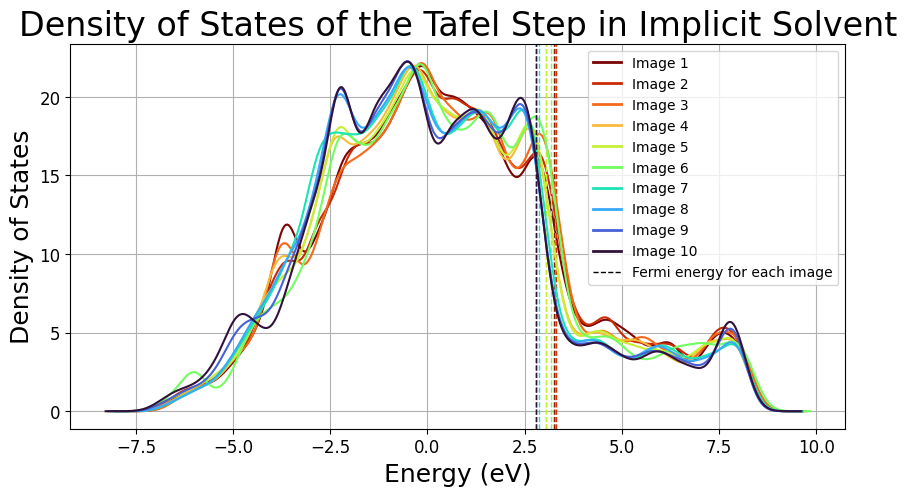

In [11]:
plt.figure(figsize=(10, 5))

# Generate evenly-spaced rainbow colors based on number of files
# Colors go from red (image 1) to purple (image 10)
n_files = len(filenames)
colors = plt.cm.turbo(np.linspace(1, 0, n_files))

# Create image names list first
image_names = []
for file in filenames:
    image_name = file.split('_')[1]
    image_name = image_name.split('.')[0]
    image_name = "Image " + image_name
    image_names.append(image_name)

# Now create legend elements with populated image_names
separate_legend_elements = []
for i, color in enumerate(colors):
    separate_legend_elements.append(Line2D([0], [0], color=color, lw=2, label=image_names[i]))
separate_legend_elements.append(Line2D([0], [0], color='black', lw=1, linestyle='--', label='Fermi energy for each image'))

for i, file in enumerate(filenames):
    data = np.loadtxt(paths_to_compare[0] + "/" + file)
    energies = data[:, 0]
    dos = data[:, 1]
    
    plt.plot(energies, dos, color=colors[i])
    plt.axvline(x=sccs_fermi_energies[i], color=colors[i], linestyle='--', lw=1)
plt.xlabel('Energy (eV)', fontsize=18)
plt.ylabel('Density of States', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Density of States of the Tafel Step in Implicit Solvent', fontsize=24)
plt.legend(handles=separate_legend_elements, loc='upper right')
plt.grid(True)
plt.show()

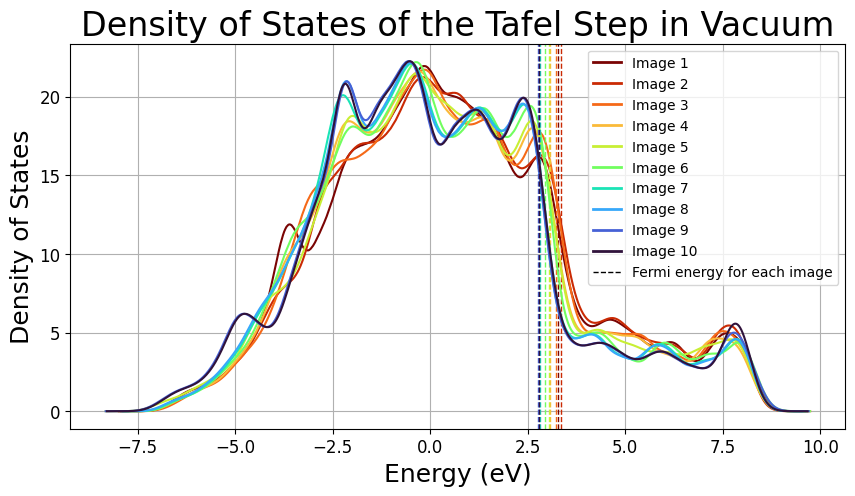

In [12]:
plt.figure(figsize=(10, 5))
for i, file in enumerate(filenames):
    data = np.loadtxt(paths_to_compare[1] + "/" + file)
    # append energies and dos to SCCS_data
    image_name = file.split('_')[1]
    image_name = image_name.split('.')[0]
    image_name = "Image " + image_name
    image_names.append(image_name)
    energies = data[:, 0]
    dos = data[:, 1]
    
    plt.plot(energies, dos, label=image_name, color=colors[i])
    plt.axvline(x=vacuum_fermi_energies[i], color=colors[i], linestyle='--', lw=1)
plt.xlabel('Energy (eV)', fontsize=18)
plt.ylabel('Density of States', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Density of States of the Tafel Step in Vacuum', fontsize=24)
plt.legend(handles=separate_legend_elements, loc='upper right')
plt.grid(True)
plt.show()

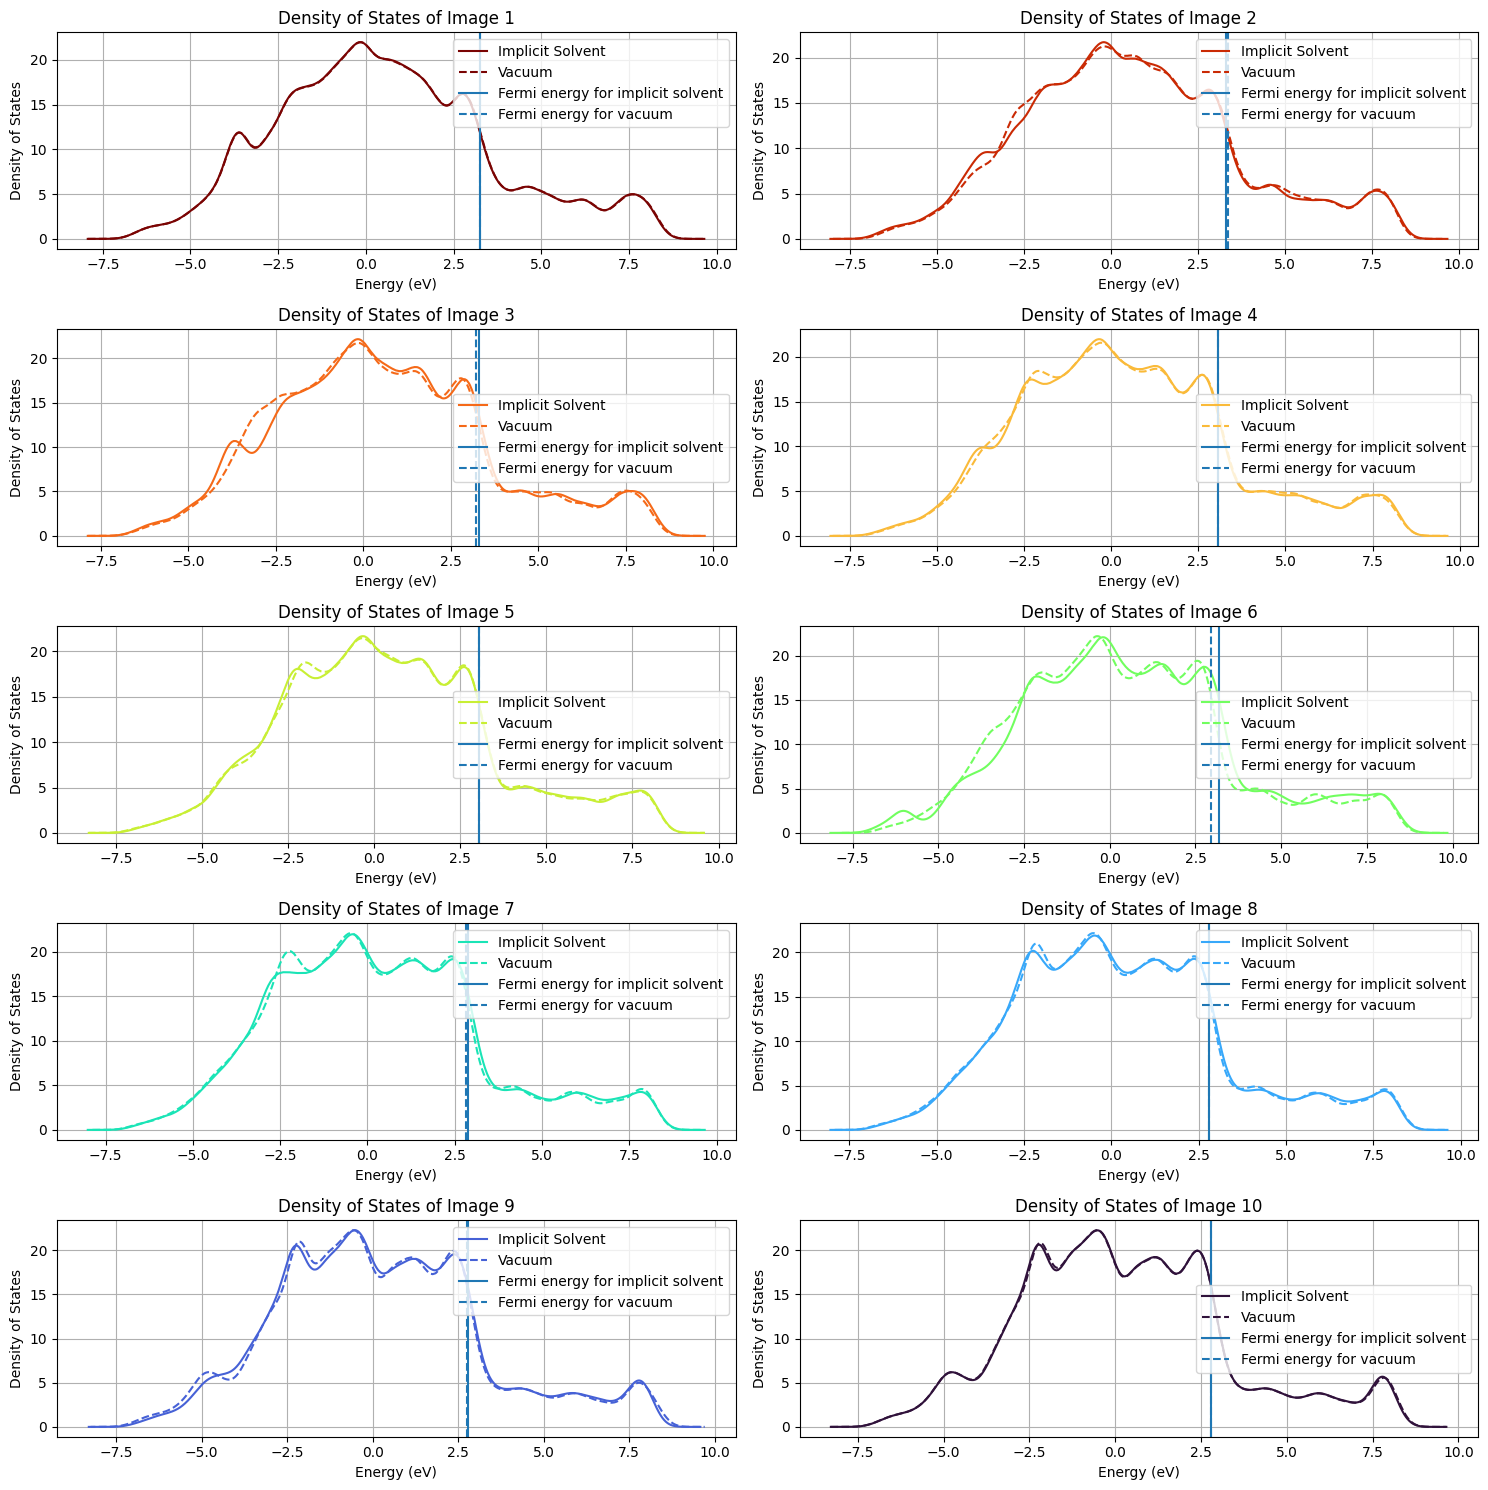

In [13]:
# Create a 2-column layout for each image, overlaying the respective SCCS and vacuum DOS of that image.
n_cols = 2
n_rows = int(np.ceil(len(filenames) / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

for i, file in enumerate(filenames):
    SCCS_data = np.loadtxt(paths_to_compare[0] + "/" + file)
    SCCS_energies = SCCS_data[:, 0]
    SCCS_dos = SCCS_data[:, 1]

    vacuum_data = np.loadtxt(paths_to_compare[1] + "/" + file)
    vacuum_energies = vacuum_data[:, 0]
    vacuum_dos = vacuum_data[:, 1]
    
    # Calculate row and column for 2-column layout
    row = i // n_cols
    col = i % n_cols

    axs[row, col].plot(SCCS_energies, SCCS_dos, color=colors[i], linestyle='-', label='Implicit Solvent')
    axs[row, col].plot(vacuum_energies, vacuum_dos, color=colors[i], linestyle='--', label='Vacuum')
    axs[row, col].set_xlabel('Energy (eV)')
    axs[row, col].set_ylabel('Density of States')
    axs[row, col].set_title('Density of States of ' + image_names[i])
    axs[row, col].axvline(x=sccs_fermi_energies[i], linestyle='-', label='Fermi energy for implicit solvent')
    axs[row, col].axvline(x=vacuum_fermi_energies[i], linestyle='--', label='Fermi energy for vacuum')
    axs[row, col].legend()
    axs[row, col].grid(True)

plt.tight_layout()
plt.show()

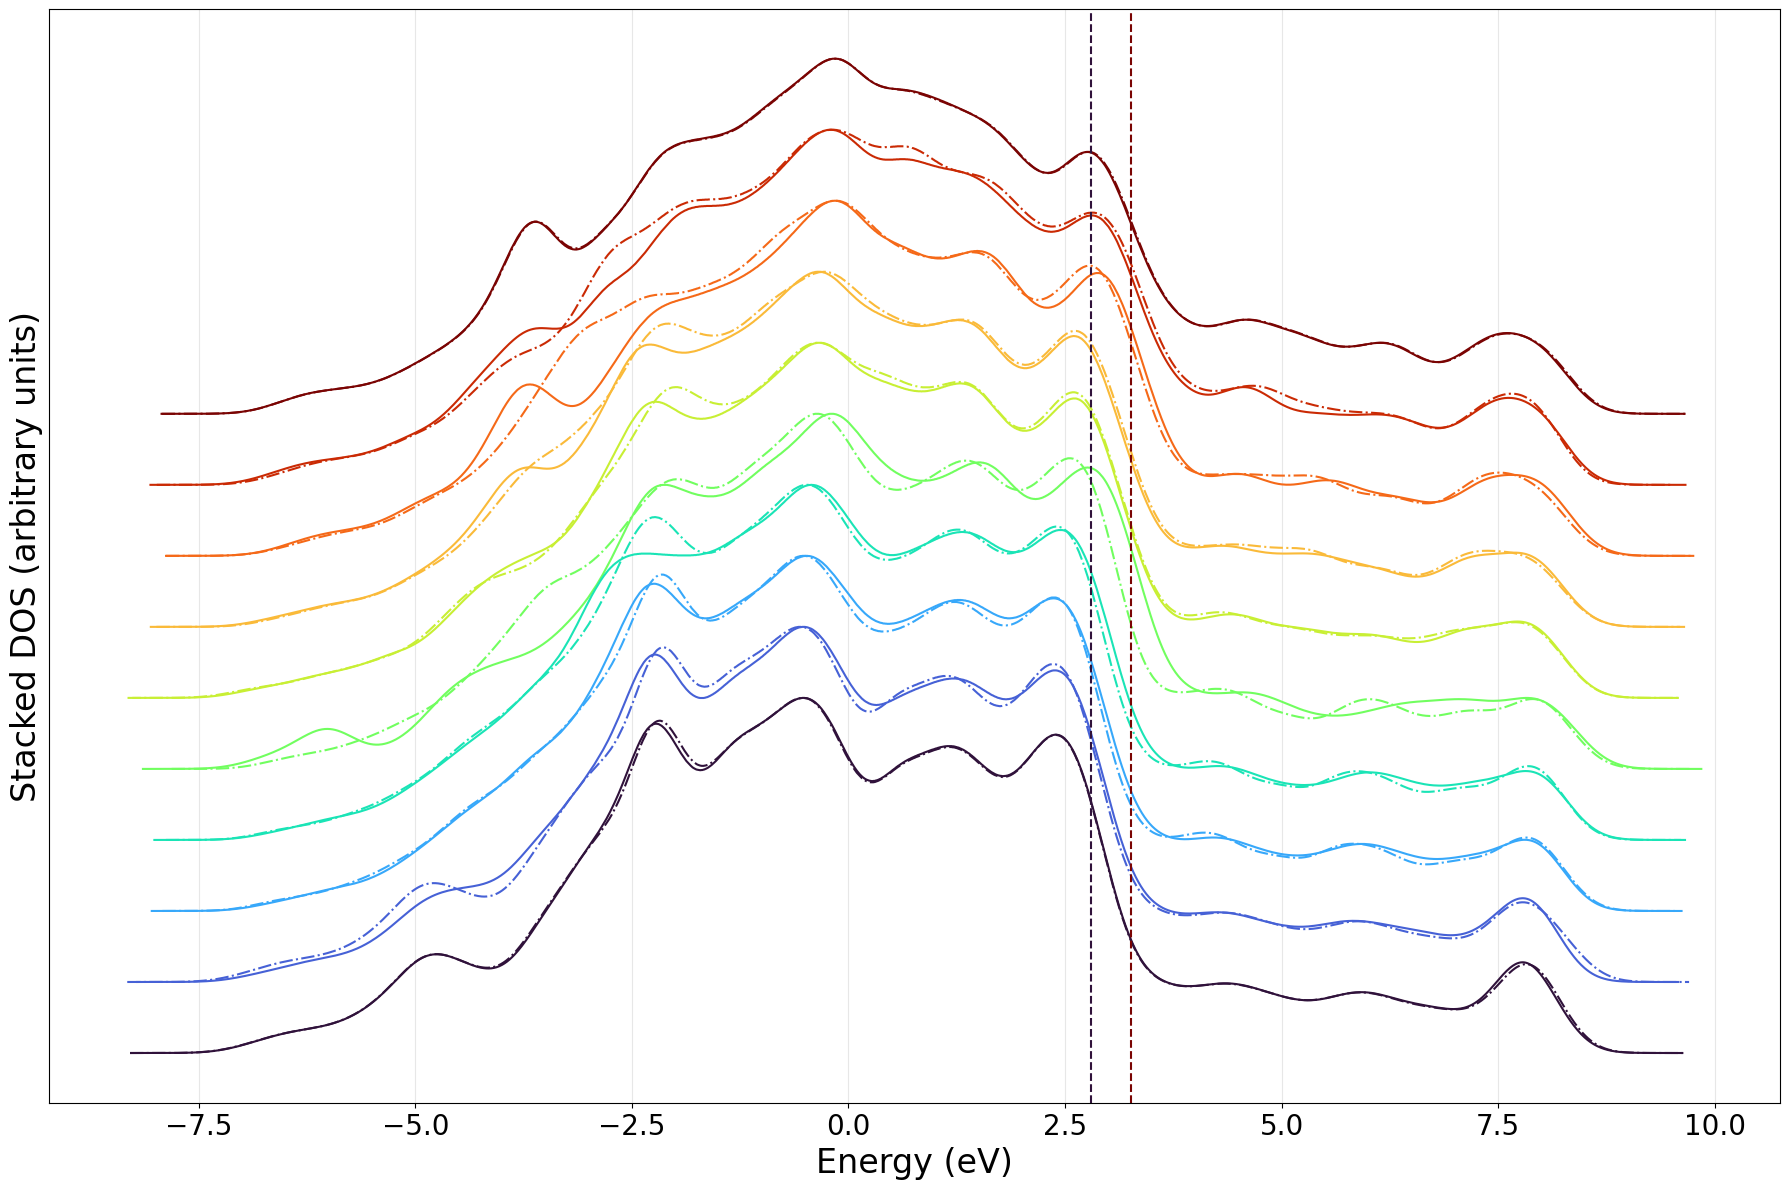

In [20]:
# Create a stacked/waterfall plot of the density of states
plt.figure(figsize=(18, 12))

# Define the vertical spacing between curves
vertical_offset = -0.2

# Custom legend
combined_legend_elements = []
for i, color in enumerate(colors):
    combined_legend_elements.append(Line2D([0], [0], color=color, lw=1, label=image_names[i]))
combined_legend_elements.append(Line2D([0],[0], color='black', lw=1, linestyle='-', label='DOS of implicit solvent image'))
combined_legend_elements.append(Line2D([0],[0], color='black', lw=1, linestyle='-.', label='DOS of vacuum image'))
combined_legend_elements.append(Line2D([0], [0], color='black', lw=0.8, linestyle='--', label='Fermi energy of implicit solvent image'))

for i, file in enumerate(filenames):
    SCCS_data = np.loadtxt(paths_to_compare[0] + "/" + file)
    SCCS_energies = SCCS_data[:, 0]
    SCCS_dos = SCCS_data[:, 1]

    vacuum_data = np.loadtxt(paths_to_compare[1] + "/" + file)
    vacuum_energies = vacuum_data[:, 0]
    vacuum_dos = vacuum_data[:, 1]
    
    # Normalize DOS to have similar amplitudes (optional, for better visualization)
    SCCS_dos_normalized = SCCS_dos / np.max(np.abs(SCCS_dos))
    vacuum_dos_normalized = vacuum_dos / np.max(np.abs(vacuum_dos))
    
    # Add vertical offset to stack the curves
    SCCS_dos_stacked = SCCS_dos_normalized + i * vertical_offset
    vacuum_dos_stacked = vacuum_dos_normalized + i * vertical_offset
    
    plt.plot(SCCS_energies, SCCS_dos_stacked, color=colors[i], linewidth=1.5, linestyle='-')
    plt.plot(vacuum_energies, vacuum_dos_stacked, color=colors[i], linewidth=1.5, linestyle='-.')
plt.xlabel('Energy (eV)', fontsize=24)
plt.ylabel('Stacked DOS (arbitrary units)', fontsize=24)
plt.xticks(fontsize=20)
plt.axvline(x=sccs_fermi_energies[0], color=colors[0], linestyle='--')
plt.axvline(x=sccs_fermi_energies[9], color=colors[9], linestyle='--')
# plt.title('Density of States of the Tafel Step in Implicit Solvent and Vacuum', fontsize=24)
# plt.legend(handles=combined_legend_elements, fontsize=18, loc='upper right', framealpha=1)
plt.grid(True, alpha=0.3)
plt.yticks([])  # Remove y-axis ticks since they're not meaningful
plt.tight_layout()
plt.show()



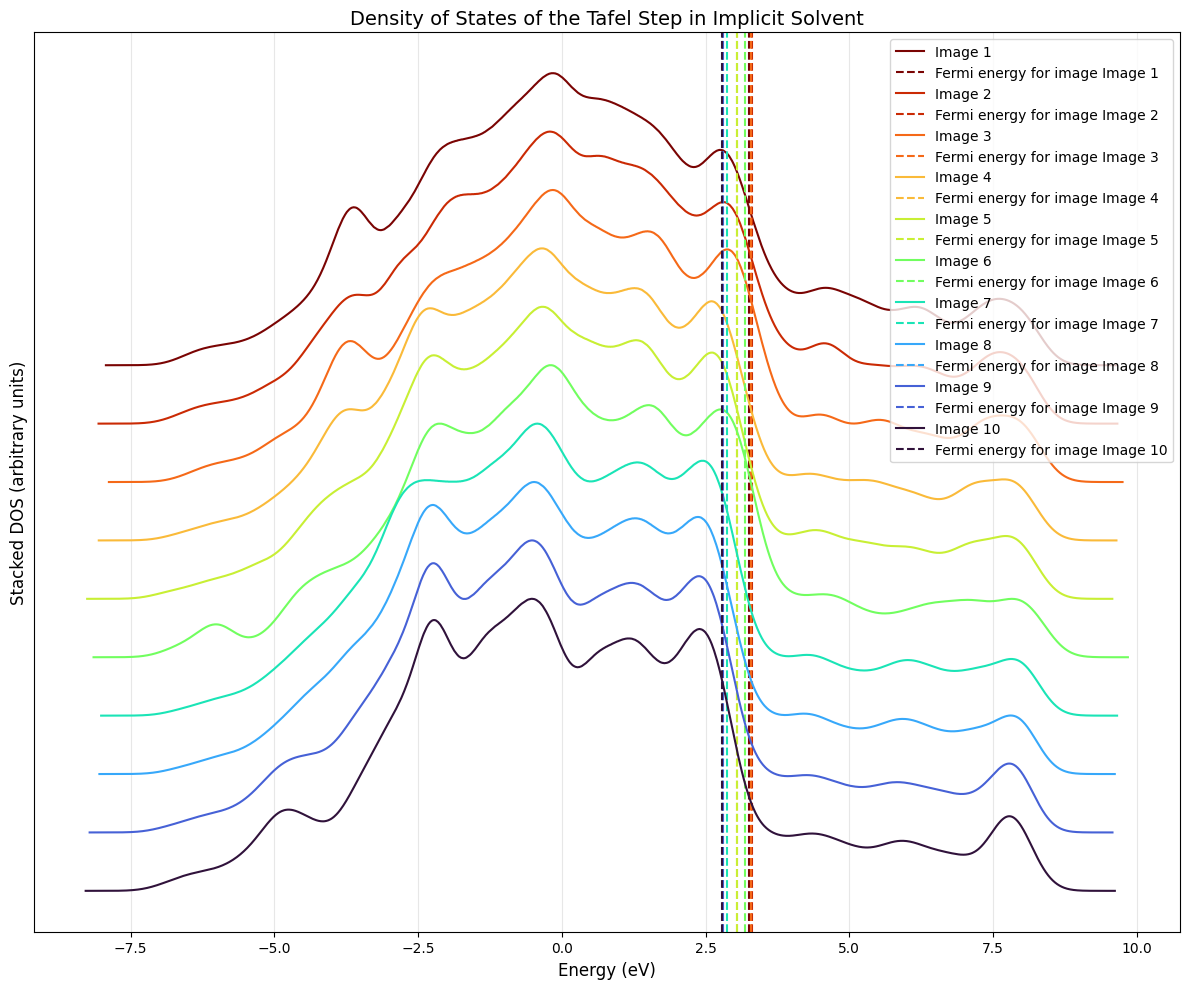

In [15]:
# Too busy! Redo separate plots for each image but do a waterfall plot

plt.figure(figsize=(12, 10))

# Define the vertical spacing between curves
vertical_offset = -0.2

for i, file in enumerate(filenames):
    SCCS_data = np.loadtxt(paths_to_compare[0] + "/" + file)
    SCCS_energies = SCCS_data[:, 0]
    SCCS_dos = SCCS_data[:, 1]
    
    # Normalize DOS to have similar amplitudes (optional, for better visualization)
    SCCS_dos_normalized = SCCS_dos / np.max(np.abs(SCCS_dos))
    
    # Add vertical offset to stack the curves
    SCCS_dos_stacked = SCCS_dos_normalized + i * vertical_offset
    
    plt.plot(SCCS_energies, SCCS_dos_stacked, label=image_names[i], color=colors[i], linewidth=1.5, linestyle='-')
    plt.axvline(x=sccs_fermi_energies[i], color=colors[i], linestyle='--', label='Fermi energy for image ' + image_names[i])
plt.xlabel('Energy (eV)', fontsize=12)
plt.ylabel('Stacked DOS (arbitrary units)', fontsize=12)
plt.title('Density of States of the Tafel Step in Implicit Solvent', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.yticks([])  # Remove y-axis ticks since they're not meaningful
plt.tight_layout()
plt.show()

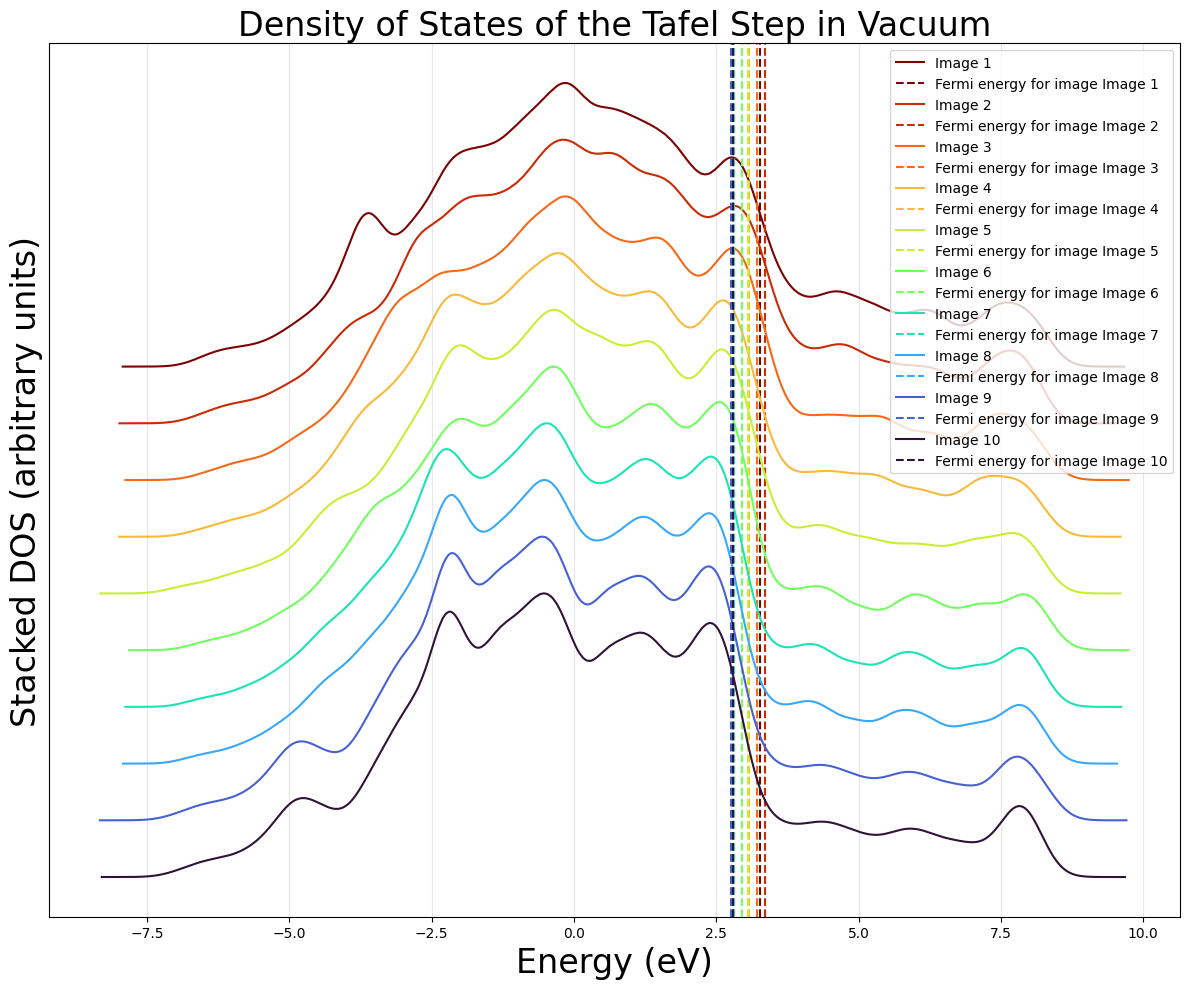

In [16]:
plt.figure(figsize=(12, 10))

# Define the vertical spacing between curves
vertical_offset = -0.2

for i, file in enumerate(filenames):

    vacuum_data = np.loadtxt(paths_to_compare[1] + "/" + file)
    vacuum_energies = vacuum_data[:, 0]
    vacuum_dos = vacuum_data[:, 1]
    
    # Normalize DOS to have similar amplitudes (optional, for better visualization)
    vacuum_dos_normalized = vacuum_dos / np.max(np.abs(vacuum_dos))
    
    # Add vertical offset to stack the curves
    vacuum_dos_stacked = vacuum_dos_normalized + i * vertical_offset
    
    plt.plot(vacuum_energies, vacuum_dos_stacked, label=image_names[i], color=colors[i], linewidth=1.5)
    plt.axvline(x=vacuum_fermi_energies[i], color=colors[i], linestyle='--', label='Fermi energy for image ' + image_names[i])
plt.xlabel('Energy (eV)', fontsize=24)
plt.ylabel('Stacked DOS (arbitrary units)', fontsize=24)
plt.title('Density of States of the Tafel Step in Vacuum', fontsize=24)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.yticks([])  # Remove y-axis ticks since they're not meaningful
plt.tight_layout()
plt.show()